# **LAYER 1B: Leakage Detection & Temporal Integrity Validation**
### **Objective:** Ensure model reliability by identifying target leakage, temporal drifts, and shortcut features in `feature_data_v4.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from scipy.stats import entropy

# Load Dataset
df = pd.read_csv('../Dataset/feature_data_v4.csv')
target = 'delivery_time_hours'

# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Numeric features identification
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target in numeric_cols:
    numeric_cols.remove(target)

print(f"✅ Loaded {len(df)} rows with {len(numeric_cols)} numeric features.")

✅ Loaded 69926 rows with 26 numeric features.


## **STEP 1: Target Leakage Scan**
Detecting features with suspiciously high correlation (>0.9) to the target variable.

In [2]:
pearson_corr = df[numeric_cols + [target]].corr(method='pearson')[target].drop(target)
spearman_corr = df[numeric_cols + [target]].corr(method='spearman')[target].drop(target)

leakage_report = pd.DataFrame({
    'Pearson': pearson_corr,
    'Spearman': spearman_corr,
    'Max_Abs_Corr': np.maximum(pearson_corr.abs(), spearman_corr.abs())
}).sort_values(by='Max_Abs_Corr', ascending=False)

flagged_leakage = leakage_report[leakage_report['Max_Abs_Corr'] > 0.9]

print("--- Top 15 Potential Leakage Candidates ---")
display(leakage_report.head(15))
print(f"\n🚩 Flagged Features: {flagged_leakage.index.tolist()}")

--- Top 15 Potential Leakage Candidates ---


,Pearson,Spearman,Max_Abs_Corr
expected_time_no_traffic,0.961760,0.977279,0.977279
distance_km,0.954333,0.971824,0.971824
route_avg_distance,0.954333,0.971824,0.971824
is_long_distance,0.807627,0.773720,0.807627
is_long_route,0.777870,0.717357,0.777870
route_frequency,0.426267,0.498060,0.498060
vehicle_distance_mismatch,0.374665,0.379768,0.379768
operational_stress_index,0.325163,0.332391,0.332391
traffic_weather_risk,0.234464,0.202360,0.234464
temperature,-0.196555,-0.095897,0.196555



🚩 Flagged Features: ['expected_time_no_traffic', 'distance_km', 'route_avg_distance']


## **STEP 2: Temporal Sanity Checks**
Simulating a time-aware split to detect target mean drift over the timeline.

In [3]:
df_sorted = df.sort_values('order_date')
split_idx = int(len(df_sorted) * 0.8)
train_df = df_sorted.iloc[:split_idx]
test_df = df_sorted.iloc[split_idx:]

print(f"Train Target Mean (Earliest 80%): {train_df[target].mean():.4f}")
print(f"Test Target Mean (Latest 20%):   {test_df[target].mean():.4f}")

Train Target Mean (Earliest 80%): 9.1738
Test Target Mean (Latest 20%):   9.0866


## **STEP 3: Shortcut Feature Detection**
Filtering constant, low-variance, and low-entropy features.

In [4]:
variance = df[numeric_cols].var()
constant_features = [col for col in numeric_cols if df[col].nunique() <= 1]
low_variance = [col for col in numeric_cols if variance[col] < 1e-5 and col not in constant_features]

def calc_entropy(col):
    counts = df[col].value_counts(normalize=True)
    return entropy(counts)

entropy_scores = {col: calc_entropy(col) for col in numeric_cols}
low_entropy = [col for col, score in entropy_scores.items() if score < 0.01]

print(f"❌ Constant Features: {constant_features}")
print(f"⚠️ Low Variance: {low_variance}")
print(f"📉 Low Entropy: {low_entropy}")

❌ Constant Features: ['night_peak_conflict', 'is_return_route', 'route_std_distance', 'city_pair_complexity']
⚠️ Low Variance: ['distance_vs_route_avg']
📉 Low Entropy: ['night_peak_conflict', 'is_return_route', 'route_std_distance', 'city_pair_complexity']


## **STEP 4: Permutation Leakage Test**
Verifying that features cannot predict a randomly shuffled target.

In [5]:
X = df[numeric_cols].fillna(0)
y_shuffled = np.random.permutation(df[target])

model = LinearRegression()
model.fit(X, y_shuffled)
permutation_r2 = r2_score(y_shuffled, model.predict(X))

print(f"Shuffled Target R²: {permutation_r2:.6f}")
if permutation_r2 > 0.05:
    print("❌ WARNING: High R² on shuffled target indicates potential identifier leakage.")
else:
    print("✅ PASS: No leakage detected via permutation test.")

Shuffled Target R²: 0.000130
✅ PASS: No leakage detected via permutation test.


## **STEP 5: Visual Evidence**

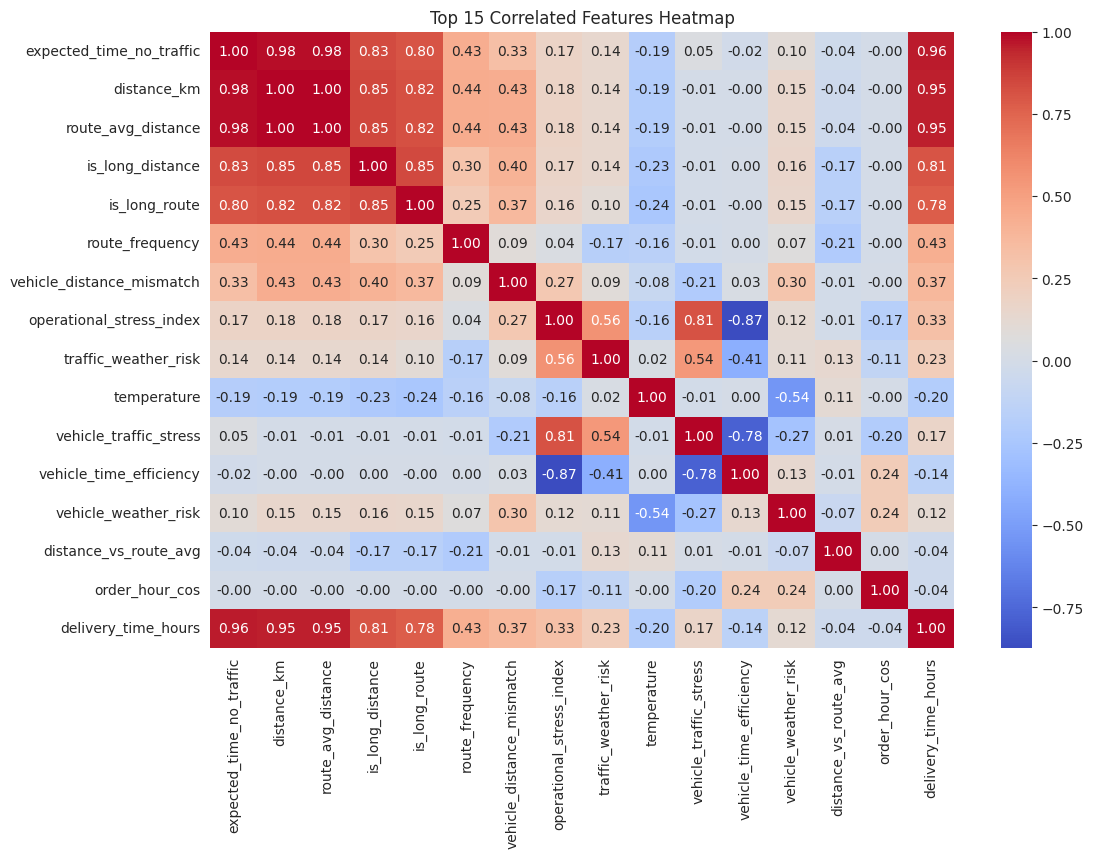

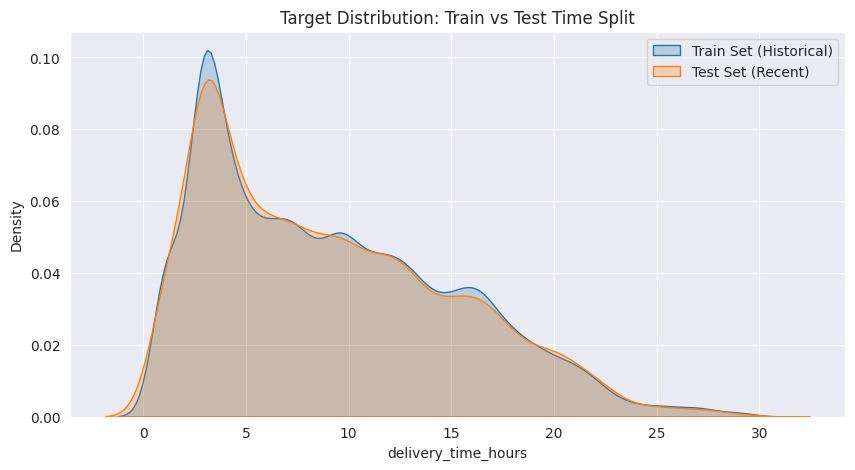

In [6]:
# Correlation Heatmap
top_15 = leakage_report.head(15).index.tolist()
plt.figure(figsize=(12, 8))
sns.heatmap(df[top_15 + [target]].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Top 15 Correlated Features Heatmap')
plt.show()

# Temporal Split Distribution
plt.figure(figsize=(10, 5))
sns.kdeplot(train_df[target], label='Train Set (Historical)', fill=True)
sns.kdeplot(test_df[target], label='Test Set (Recent)', fill=True)
plt.title('Target Distribution: Train vs Test Time Split')
plt.legend()
plt.show()